In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import ConcreteModel, Set, Param, Var, Objective, Constraint, SolverFactory, NonNegativeReals, minimize, Reals, Binary, value



## Get Data

In [114]:
np.random.seed(40)  # Use any number you want

#get fixed data
def get_fixed_data():
    """
    Returns the fixed data for the energy hub simulation.
    """
    num_timeslots = 24
    return {
        # Conversion efficiencies
        'conversion_p2h': 0.9,
        'conversion_h2p': 0.8,

        # Hydrogen storage capacity
        'hydrogen_capacity': 15,
        
        'p2h_max_rate': 5,
        'h2p_max_rate': 5,

        # Electrolyzer cost
        'electrolyzer_cost': 1, 

        # Wind model parameters
        'target_mean_wind': 4.5,
        'wind_reversion_strength': 0.15,
        'extreme_event_prob_wind': 0.03,

        # Price model parameters
        'mean_price': 35,
        'price_reversion_strength': 0.12,
        'wind_influence_on_price': -0.6,
        'price_cap': 90,  
        'price_floor': 0,
        
        
        'num_timeslots': num_timeslots,
        'demand_schedule': [5 + 2 * np.sin(2 * np.pi * t / 24) for t in range(num_timeslots)]

        
    }

data = get_fixed_data()

def price_model(current_price, previous_price, projected_wind, data):
    """
    Price process with dependence on previous prices and projected wind generation.

    Args:
        current_price (float): Current electricity price.
        previous_price (float): Electricity price at the previous time step.
        projected_wind (float): Projected wind generation for the next time step.
        data (dict): Fixed data containing model parameters.

    Returns:
        float: Next price.
    """
    mean_price = data['mean_price']
    reversion_strength = data['price_reversion_strength']
    wind_influence = data['wind_influence_on_price']
    price_cap = data['price_cap']
    price_floor = data['price_floor']

    mean_reversion = reversion_strength * (mean_price - current_price)
    wind_effect = wind_influence * projected_wind
    noise = np.random.normal(0, 1)

    next_price = current_price + 0.6 * (current_price - previous_price) + mean_reversion + wind_effect + noise

    if next_price < 0:
        if np.random.rand() > 0.2:
            next_price = np.random.uniform(0, mean_price * 0.3)

    return max(min(next_price, price_cap), price_floor)

def wind_model(current_wind, data):
    """
    Wind generation process with mean reversion and extreme events.

    Args:
        current_wind (float): Current wind generation.
        data (dict): Fixed data containing model parameters.

    Returns:
        float: Next wind generation.
    """
    target_mean = data['target_mean_wind']
    reversion_strength = data['wind_reversion_strength']
    extreme_event_prob = data['extreme_event_prob_wind']

    mean_reversion = reversion_strength * (target_mean - current_wind)
    noise = np.random.normal(0, 1)

    next_wind = current_wind + mean_reversion + noise

    if np.random.rand() < extreme_event_prob:
        next_wind += np.random.uniform(10, 20)

    return max(next_wind, 0)

def simulate_energy_hub(data, num_steps=100):
    """
    Simulates the energy hub over a specified number of time steps.

    Args:
        data (dict): Fixed data containing model parameters.
        num_steps (int): Number of time steps to simulate.

    Returns:
        pd.DataFrame: DataFrame containing the simulation results.
    """
    results = {
        'time': [],
        'price': [],
        'wind_generation': [],
        'demand': []
    }

    current_price = data['mean_price']
    previous_price = current_price
    current_wind = data['target_mean_wind']

    for t in range(num_steps):
        projected_wind = wind_model(current_wind, data)
        next_price = price_model(current_price, previous_price, projected_wind, data)

        results['time'].append(t)
        results['price'].append(next_price)
        results['wind_generation'].append(projected_wind)
        results['demand'].append(data['demand_schedule'][t % data['num_timeslots']])

        previous_price = current_price
        current_price = next_price
        current_wind = projected_wind

    return pd.DataFrame(results)

# Run the simulation
#simulation_results = simulate_energy_hub(data, num_steps=100)
#print(simulation_results.head())


## Pseudo code

In [115]:
class EnergySystemValidator:
    def __init__(self, p2h_max, h2p_max, r_h2p_efficiency):
        self.p2h_max = p2h_max
        self.h2p_max = h2p_max
        self.r_h2p = r_h2p_efficiency

    @staticmethod
    def check_feasibility(state, decision, demand, data):
        """
        Returns (is_valid, error_message)
        """
        p2h_max = data['p2h_max_rate']
        h2p_max = data['h2p_max_rate']
        r_h2p = data['conversion_h2p']
        
        # 1. Capacity Checks
        if decision['p_p2h'] > p2h_max:
            return False, "Exceeds P2H capacity"
        
        if decision['h_h2p'] > h2p_max:
            return False, "Exceeds H2P capacity"

        # 2. Grid Balancing Check
        # The grid must balance the wind, demand, and hydrogen conversions
        expected_grid = (demand + decision['p_p2h'] - 
                         state['p_wind'] - (r_h2p * decision['h_h2p']))
        expected_grid = max(0, expected_grid)  # Grid cannot be negative (no selling back in this model)
        
        if abs(decision['p_grid'] - expected_grid) > 1e-6:
            return False, f"Power imbalance: Grid={decision['p_grid']}, Expected={expected_grid}"

        # 3. Binary and Switching Logic
        y_act, y_de = decision['y_act'], decision['y_de']
        
        if y_act not in [0, 1] or y_de not in [0, 1]:
            return False, "Activation signals must be 0 or 1"
            
        if (y_act * y_de) != 0:
            return False, "Cannot activate and deactivate at the same time"

        return True, "Valid"
    
    @staticmethod
    def get_dummy_action(state, demand, params):

        
    #"""
    #Creates a safe, 'do-nothing' feasible action when the policy fails.
    # This ensures the simulation can continue without crashing.
    #"""
    # 1. Default to no hydrogen conversion
        p_p2h_dummy = 0.0
        h_h2p_dummy = 0.0
    
    # 2. Binary signals: Stay in current state (no activation or deactivation)
        y_act_dummy = 0
        y_de_dummy = 0
    
    # 3. Force Grid Balance
    # Following the equation: p_grid = D_t + p_p2h - p_wind - (R_h2p * h_h2p)
    # With dummy hydrogen values at 0, the grid simply covers net demand
        p_grid_dummy = demand - state['p_wind']
        p_grid_dummy = max(0, p_grid_dummy)  # Ensure grid is not negative
    
        return {
        'p_p2h': p_p2h_dummy,
        'h_h2p': h_h2p_dummy,
        'p_grid': p_grid_dummy,
        'y_act': y_act_dummy,
        'y_de': y_de_dummy
    }

    def decision_to_dict(self, decision):
        return {
            'p_p2h': decision['p_p2h'],
            'h_h2p': decision['h_h2p'],
            'p_grid': decision['p_grid'],
            'y_act': decision['y_act'],
            'y_de': decision['y_de']
        }
    
    @staticmethod
    def cost_function(decision, price):
        """
        Calculates the cost of a given decision based on the current price and parameters.
        """
        # Cost from grid consumption
        grid_cost = decision['p_grid'] * price

        
        return grid_cost
    
    @staticmethod
    def apply_dynamics(state, u, data):
        """
        Applies the transition dynamics to move from state t to state t+1.
        
        Args:
            state (dict): Current state variables {h, y, p_wind, lambda_grid, ...}
            u (dict): Decisions made at time t {p_p2h, h_h2p, y_act, y_de}
            data (dict): Parameters including efficiencies and model constants
            
        Returns:
            dict: The updated state for the next time step (t+1)
        """
        next_state = {}
        
        # 1. Hydrogen Storage Transition: h_{t+1} = h_t + (p_p2h * R_p2h) - h_h2p
        # R_p2h is the 'conversion_p2h' (0.9) from your fixed data
        next_state['h'] = state['h'] + (u['p_p2h'] * data['conversion_p2h']) - u['h_h2p']
        
        # 2. System Status Transition: y_{t+1} = y_t + y_act - y_de
        next_state['y'] = state['y'] + u['y_act'] - u['y_de']
        
        # 3. Store current values as 'previous' for the next step's stochastic models
        next_state['p_wind_prev'] = state['p_wind']
        next_state['lambda_grid_prev'] = state['lambda_grid']
        
        # 4. Stochastic Wind Transition: p_{t+1} ~ P(.|p_t)
        # Uses your wind_model with mean reversion and extreme event logic
        next_state['p_wind'] = wind_model(state['p_wind'], data)
        
        # 5. Stochastic Price Transition: lambda_{t+1} ~ P(.|lambda_t, lambda_prev, wind_next)
        # Uses your price_model which depends on the newly sampled wind
        next_state['lambda_grid'] = price_model(
            current_price=state['lambda_grid'],
            previous_price=state['lambda_grid_prev'],
            projected_wind=next_state['p_wind'],
            #previous_wind=next_state['p_wind_prev'],
            data=data
        )
        
        return next_state
    
    @staticmethod
    def hierarchical_policy(state, demand):
        """
        Policy Priorities:
        1. Wind Power (First)
        2. Hydrogen Storage (Excess wind -> P2H | Deficit -> H2P)
        3. Grid (Last resort for deficits)
        """
        # Parameters from fixed data
        h_max = data['hydrogen_capacity']
        p2h_limit = data['p2h_max_rate']
        h2p_limit = data['h2p_max_rate']
        r_p2h = data['conversion_p2h']
        r_h2p = data['conversion_h2p']

        
        # Initialize decisions
        p_p2h = 0.0
        h_h2p = 0.0
        y_act = 0
        y_de = 0

        # Step 1: Calculate the immediate balance after Wind
        # surplus > 0 means we have extra energy; surplus < 0 means we have a deficit
        surplus = state['p_wind'] - demand

        if surplus > 0:
            # --- CASE A: EXCESS WIND ---
            # Calculate how much hydrogen the tank can still hold
            room_in_tank = h_max - state['h']
            
            # Max power we can convert is limited by room in tank AND machine capacity
            # We need to divide room_in_tank by r_p2h to see how much POWER can be absorbed
            #p_p2h = min(surplus, p2h_limit, room_in_tank / r_p2h)
            p_p2h = min(float(surplus), p2h_limit, float(room_in_tank / r_p2h))
            
        elif surplus < 0:
            # --- CASE B: ENERGY DEFICIT ---
            deficit = abs(surplus)
            
            # Try to meet the deficit with Hydrogen-to-Power
            # Limited by available hydrogen AND machine capacity
            # We can produce r_h2p units of power for every 1 unit of hydrogen
            max_h2p_output = min(state['h'] * r_h2p, h2p_limit * r_h2p)
            
            # Power provided by hydrogen (cannot exceed the deficit)
            p_from_h2p = min(deficit, max_h2p_output)
            
            # Convert power back to hydrogen units for the decision dictionary
            h_h2p = p_from_h2p / r_h2p

        # Step 3: Grid Balance
        # The Grid must cover exactly what Wind and H2P couldn't meet, 
        # plus any Power-to-Hydrogen consumption we chose to do.
        # Formula: p_grid = Demand + p_p2h - Wind - (r_h2p * h_h2p)
        p_grid = demand + p_p2h - state['p_wind'] - (r_h2p * h_h2p)
        p_grid = max(0, p_grid)  # Grid cannot be negative (no selling back in this model)
        
        # Final check: p_grid should not be negative in this specific hierarchy
        p_grid = max(0, p_grid)

        return {
            'p_p2h': p_p2h,
            'h_h2p': h_h2p,
            'p_grid': p_grid,
            'y_act': y_act,
            'y_de': y_de
        }
    

In [116]:
# Store results for plotting
results = {
    'timestep': [],
    'p_p2h': [],
    'h_h2p': [],
    'p_grid': [],
    'cost': [],
    'hydrogen_level': [],
    'wind': [],
    'demand': [],
    'price': []
}

for t in range(1, 24):
    init_state = {
        'h': 5.0,  # Initial hydrogen storage level
        'y': 0,    # Initial system status (inactive)
        'p_wind': 4.0,  # Initial wind generation
        'lambda_grid': 30.0,  # Initial electricity price
        'p_wind_prev': 4.0,  # Previous wind generation
        'lambda_grid_prev': 30.0  # Previous electricity price
    
    }

    if t == 1:
        policy = EnergySystemValidator.hierarchical_policy(init_state, data['demand_schedule'][t])
        #dummy_decision = EnergySystemValidator.get_dummy_action(init_state, data['demand_schedule'][t], data)
        state = EnergySystemValidator.apply_dynamics(init_state, policy, data)
        decision = EnergySystemValidator.hierarchical_policy(state, data['demand_schedule'][t])
        is_feasible, error_message = EnergySystemValidator.check_feasibility(state, decision, data['demand_schedule'][t],data)
        if not is_feasible:
            print(f"Policy infeasible at time {t}, using dummy action.")
            print(f"Error: {error_message}")
            decision = EnergySystemValidator.get_dummy_action(state, data['demand_schedule'][t], data)
        cost = EnergySystemValidator.cost_function(decision, state['lambda_grid'])
        next_state = EnergySystemValidator.apply_dynamics(state, decision, data) 
    else: 
        state = next_state
        decision = EnergySystemValidator.hierarchical_policy(state, data['demand_schedule'][t])
        is_feasible, error_message = EnergySystemValidator.check_feasibility(state, decision, data['demand_schedule'][t],data)
        if not is_feasible:
            print(f"Policy infeasible at time {t}, using dummy action.")
            print(f"Error: {error_message}")
            decision = EnergySystemValidator.get_dummy_action(state, data['demand_schedule'][t], data)
        cost = EnergySystemValidator.cost_function(decision, state['lambda_grid'])
        next_state = EnergySystemValidator.apply_dynamics(state, decision, data)
    
    # Store results
    results['timestep'].append(t)
    results['p_p2h'].append(decision['p_p2h'])
    results['h_h2p'].append(decision['h_h2p'])
    results['p_grid'].append(decision['p_grid'])
    results['cost'].append(cost)
    results['hydrogen_level'].append(state['h'])
    results['wind'].append(state['p_wind'])
    results['demand'].append(data['demand_schedule'][t])
    results['price'].append(state['lambda_grid'])
    
    print(f"Time step {t}:")
    print(f"cost: {cost:.2f}, wind: {state['p_wind']:.2f}, price: {state['lambda_grid']:.2f}, hydrogen level: {state['h']:.2f}")
    print(f"demand: {data['demand_schedule'][t]}")
    



Time step 1:
cost: 0.00, wind: 3.47, price: 28.39, hydrogen level: 3.10
demand: 5.5176380902050415
Time step 2:
cost: 57.86, wind: 3.21, price: 24.52, hydrogen level: 0.54
demand: 6.0
Time step 3:
cost: 14.77, wind: 5.69, price: 20.53, hydrogen level: 0.00
demand: 6.414213562373095
Time step 4:
cost: 0.00, wind: 6.74, price: 16.22, hydrogen level: 0.00
demand: 6.732050807568877
Time step 5:
cost: 19.19, wind: 5.39, price: 12.52, hydrogen level: 0.01
demand: 6.931851652578136
Time step 6:
cost: 21.92, wind: 4.74, price: 9.68, hydrogen level: 0.00
demand: 7.0
Time step 7:
cost: 15.75, wind: 4.99, price: 8.13, hydrogen level: 0.00
demand: 6.931851652578136
Time step 8:
cost: 0.00, wind: 7.23, price: 6.23, hydrogen level: 0.00
demand: 6.732050807568878
Time step 9:
cost: 0.00, wind: 8.37, price: 3.20, hydrogen level: 0.45
demand: 6.414213562373095
Time step 10:
cost: 0.00, wind: 5.86, price: 2.14, hydrogen level: 2.22
demand: 6.0
Time step 11:
cost: 0.00, wind: 4.32, price: 3.06, hydrogen 

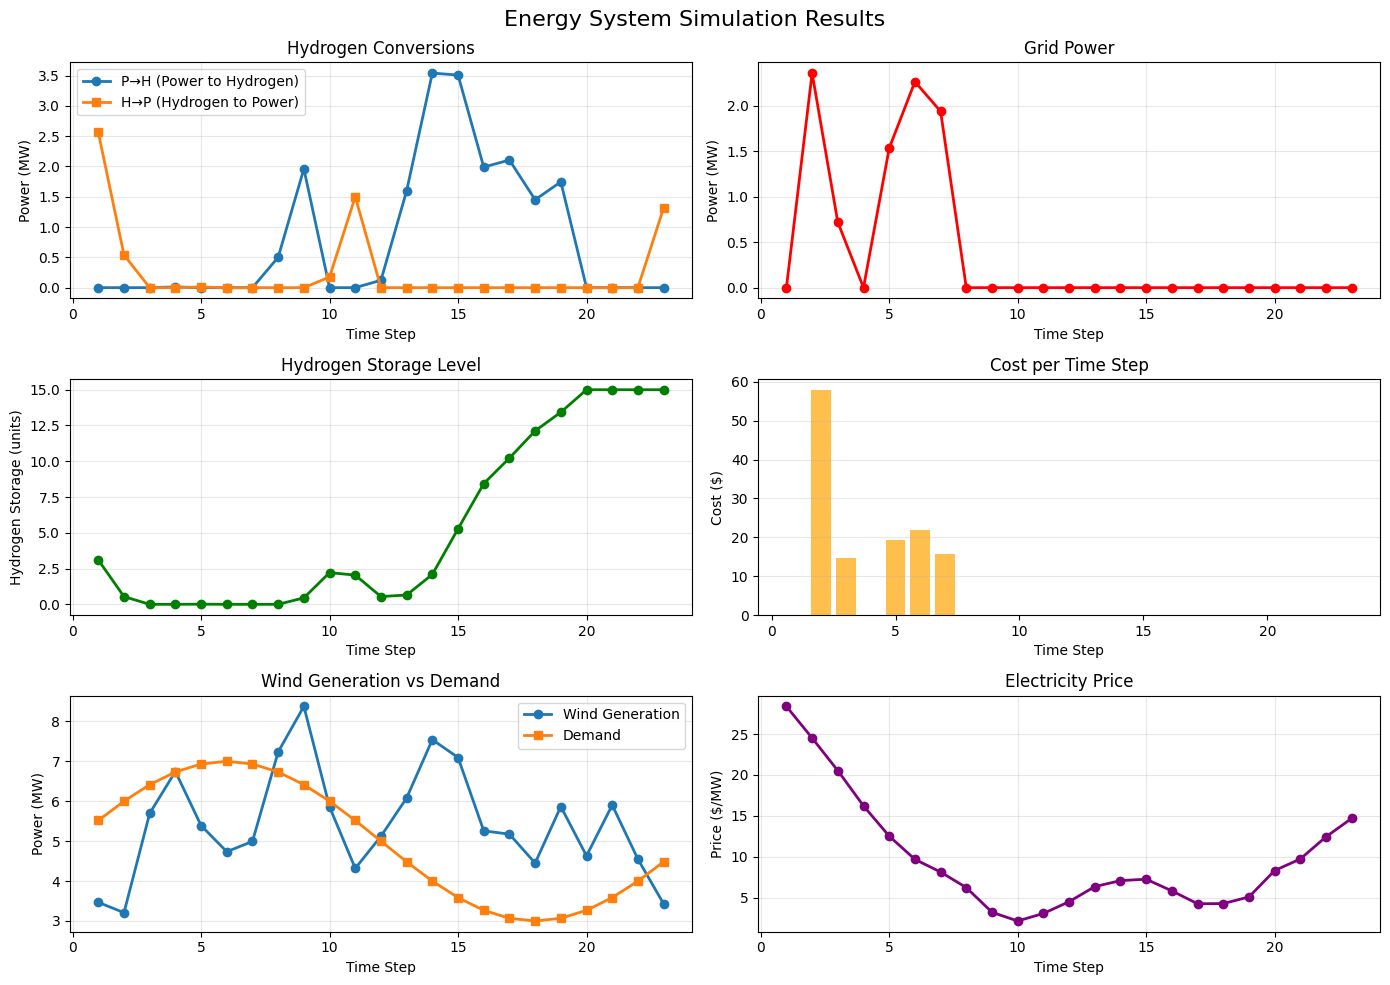


=== SUMMARY STATISTICS ===
Total Cost: $129.49
Average Cost per Time Step: $5.63
Average Grid Power: 0.38 MW
Average Hydrogen Level: 5.27 units
Max Hydrogen Level: 15.00 units
Min Hydrogen Level: 0.00 units


In [117]:
import matplotlib.pyplot as plt

# Create a figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Energy System Simulation Results', fontsize=16)

# Plot 1: Power to Hydrogen and Hydrogen to Power
ax = axes[0, 0]
ax.plot(results['timestep'], results['p_p2h'], marker='o', label='P→H (Power to Hydrogen)', linewidth=2)
ax.plot(results['timestep'], results['h_h2p'], marker='s', label='H→P (Hydrogen to Power)', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Power (MW)')
ax.set_title('Hydrogen Conversions')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Grid Power
ax = axes[0, 1]
ax.plot(results['timestep'], results['p_grid'], marker='o', color='red', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Power (MW)')
ax.set_title('Grid Power')
ax.grid(True, alpha=0.3)

# Plot 3: Hydrogen Storage Level
ax = axes[1, 0]
ax.plot(results['timestep'], results['hydrogen_level'], marker='o', color='green', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Hydrogen Storage (units)')
ax.set_title('Hydrogen Storage Level')
ax.grid(True, alpha=0.3)

# Plot 4: Cost per Time Step
ax = axes[1, 1]
ax.bar(results['timestep'], results['cost'], color='orange', alpha=0.7)
ax.set_xlabel('Time Step')
ax.set_ylabel('Cost ($)')
ax.set_title('Cost per Time Step')
ax.grid(True, alpha=0.3, axis='y')

# Plot 5: Wind vs Demand
ax = axes[2, 0]
ax.plot(results['timestep'], results['wind'], marker='o', label='Wind Generation', linewidth=2)
ax.plot(results['timestep'], results['demand'], marker='s', label='Demand', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Power (MW)')
ax.set_title('Wind Generation vs Demand')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Price
ax = axes[2, 1]
ax.plot(results['timestep'], results['price'], marker='o', color='purple', linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Price ($/MW)')
ax.set_title('Electricity Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total Cost: ${sum(results['cost']):.2f}")
print(f"Average Cost per Time Step: ${sum(results['cost'])/len(results['cost']):.2f}")
print(f"Average Grid Power: {sum(results['p_grid'])/len(results['p_grid']):.2f} MW")
print(f"Average Hydrogen Level: {sum(results['hydrogen_level'])/len(results['hydrogen_level']):.2f} units")
print(f"Max Hydrogen Level: {max(results['hydrogen_level']):.2f} units")
print(f"Min Hydrogen Level: {min(results['hydrogen_level']):.2f} units")
